# Dental Symptom Classifier — Phase 2 ML Training
**Đồ án Phòng Khám Nha | Nhóm 2**

So sánh 3 model: Naive Bayes · SVM + TF-IDF · PhoBERT

Dataset: `dental_dataset.csv` — 1086 câu tiếng Việt, 8 nhãn

## 0. Cài đặt thư viện

In [1]:
!pip install underthesea -q
!pip install transformers sentencepiece -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.3 MB/s eta 0:00:00


## 1. Import & cấu hình

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from underthesea import word_tokenize

RANDOM_STATE = 42
TEST_SIZE    = 0.2
LABELS = ['sau_rang','viem_nuou','e_buot','rang_khon','chinh_nha','tham_my','mat_rang','khac']

print('✅ Import xong')

✅ Import xong


## 2. Load & khám phá dữ liệu

In [3]:
# Tự scan tìm file CSV — không cần sửa tay
CSV_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f == 'dental_dataset.csv':
            CSV_PATH = os.path.join(root, f)
            break

if CSV_PATH is None:
    raise FileNotFoundError('Không tìm thấy dental_dataset.csv trong /kaggle/input — hãy add dataset vào notebook')

print(f'✅ Tìm thấy: {CSV_PATH}')
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
print(df['label'].value_counts())
df.head()

✅ Tìm thấy: /kaggle/input/datasets/hienhoang1/dental-dataset/dental_dataset.csv
Shape: (1086, 2)
label
khac         268
sau_rang     120
mat_rang     120
e_buot       120
viem_nuou    120
rang_khon    118
chinh_nha    111
tham_my      109
Name: count, dtype: int64


,text,label
0,Răng bị hôi miệng nên đánh răng như thế nào?,khac
1,Răng hàm dưới bị hôi miệng phải làm sao?,khac
2,Niềng răng trong suốt Invisalign có hiệu quả k...,chinh_nha
3,Niềng răng có cần nhịn ăn gì không?,chinh_nha
4,Có cách nào phòng ngừa sâu răng hiệu quả tại n...,sau_rang


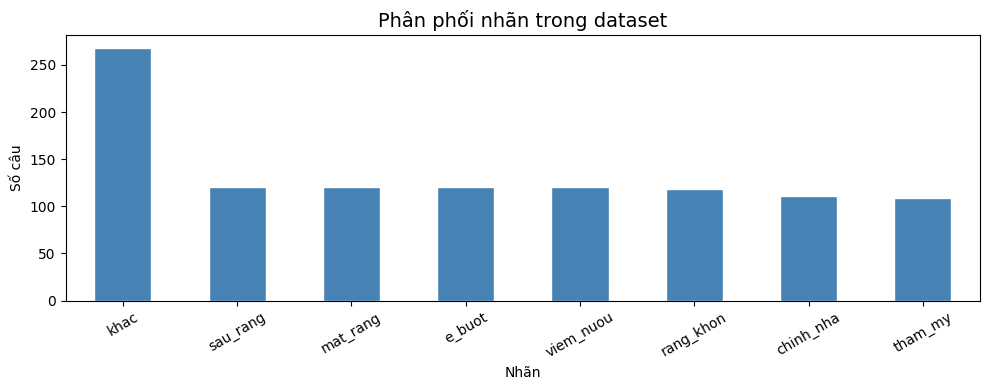

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
df['label'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Phân phối nhãn trong dataset', fontsize=14)
ax.set_xlabel('Nhãn')
ax.set_ylabel('Số câu')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

## 3. Tiền xử lý văn bản

In [5]:
def preprocess(text: str) -> str:
    text = text.strip().lower()
    return word_tokenize(text, format='text')

sample = df['text'].iloc[0]
print(f'Gốc:   {sample}')
print(f'Xử lý: {preprocess(sample)}')

Gốc:   Răng bị hôi miệng nên đánh răng như thế nào?
Xử lý: răng bị hôi_miệng nên đánh_răng như_thế_nào ?


In [6]:
print('Đang word-segment toàn bộ dataset (~1-2 phút)...')
df['text_processed'] = df['text'].apply(preprocess)
print('✅ Xong')
df[['text','text_processed','label']].head()

Đang word-segment toàn bộ dataset (~1-2 phút)...
✅ Xong


,text,text_processed,label
0,Răng bị hôi miệng nên đánh răng như thế nào?,răng bị hôi_miệng nên đánh_răng như_thế_nào ?,khac
1,Răng hàm dưới bị hôi miệng phải làm sao?,răng hàm dưới bị hôi_miệng phải làm_sao ?,khac
2,Niềng răng trong suốt Invisalign có hiệu quả k...,niềng răng trong suốt invisalign có hiệu_quả k...,chinh_nha
3,Niềng răng có cần nhịn ăn gì không?,niềng răng có cần nhịn ăn gì không ?,chinh_nha
4,Có cách nào phòng ngừa sâu răng hiệu quả tại n...,có cách nào phòng_ngừa sâu răng hiệu_quả tại n...,sau_rang


## 4. Train/Test split

In [7]:
X = df['text_processed'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train)} câu')
print(f'Test:  {len(X_test)} câu')

Train: 868 câu
Test:  218 câu


## 5. Model 1 — Naive Bayes (baseline)

In [8]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=20000,
        sublinear_tf=True
    )),
    ('clf', MultinomialNB(alpha=0.1))
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb, average='macro')

print(f'Naive Bayes — Accuracy: {acc_nb:.4f} | Macro F1: {f1_nb:.4f}')
print()
print(classification_report(y_test, y_pred_nb, target_names=LABELS))

Naive Bayes — Accuracy: 0.8807 | Macro F1: 0.8708

              precision    recall  f1-score   support

    sau_rang       0.86      0.82      0.84        22
   viem_nuou       0.83      0.79      0.81        24
      e_buot       0.91      0.96      0.94        54
   rang_khon       0.88      0.88      0.88        24
   chinh_nha       0.88      0.88      0.88        24
     tham_my       0.87      0.83      0.85        24
    mat_rang       0.88      0.95      0.91        22
        khac       0.91      0.83      0.87        24

    accuracy                           0.88       218
   macro avg       0.87      0.87      0.87       218
weighted avg       0.88      0.88      0.88       218



## 6. Model 2 — SVM + TF-IDF

In [9]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=30000,
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='macro')

print(f'SVM — Accuracy: {acc_svm:.4f} | Macro F1: {f1_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=LABELS))

SVM — Accuracy: 0.9541 | Macro F1: 0.9507

              precision    recall  f1-score   support

    sau_rang       0.88      0.95      0.91        22
   viem_nuou       0.96      0.92      0.94        24
      e_buot       0.96      0.98      0.97        54
   rang_khon       0.92      1.00      0.96        24
   chinh_nha       1.00      1.00      1.00        24
     tham_my       0.96      0.92      0.94        24
    mat_rang       0.95      0.95      0.95        22
        khac       1.00      0.88      0.93        24

    accuracy                           0.95       218
   macro avg       0.95      0.95      0.95       218
weighted avg       0.96      0.95      0.95       218



## 7. Model 3 — PhoBERT

> **Lưu ý:** Cell này dùng CPU nếu GPU bị lỗi CUDA. Với dataset 1086 câu, CPU mất ~25-35 phút.
> Nếu muốn dùng GPU: đổi `FORCE_CPU = True` thành `False` — chỉ làm nếu Kaggle GPU không báo lỗi.

In [10]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# ── Đổi thành False nếu muốn thử GPU ──
FORCE_CPU = False

if FORCE_CPU:
    DEVICE = 'cpu'
else:
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA: {torch.version.cuda}')

MODEL_NAME = 'vinai/phobert-base'
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 5
LR         = 2e-5

# Label encoding
le = LabelEncoder()
le.fit(LABELS)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
NUM_LABELS  = len(LABELS)

print('Labels:', list(le.classes_))

Device: cpu
Labels: [np.str_('chinh_nha'), np.str_('e_buot'), np.str_('khac'), np.str_('mat_rang'), np.str_('rang_khon'), np.str_('sau_rang'), np.str_('tham_my'), np.str_('viem_nuou')]


In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✅ Tokenizer loaded')

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded


In [12]:
class DentalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts   = texts
        self.labels  = labels
        self.tok     = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
            return_token_type_ids=False  # PhoBERT không dùng token_type_ids
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = DentalDataset(X_train, y_train_enc, tokenizer, MAX_LEN)
test_dataset  = DentalDataset(X_test,  y_test_enc,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 28 | Test batches: 7


In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

total_params = sum(p.numel() for p in model.parameters())
print(f'✅ PhoBERT loaded trên {DEVICE}')
print(f'Tổng params: {total_params:,}')

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

✅ PhoBERT loaded trên cpu
Tổng params: 135,004,424


In [14]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())
    return np.array(all_preds), np.array(all_labels)


history  = []
best_f1  = 0

print(f'Bắt đầu train PhoBERT trên {DEVICE}...')
if DEVICE == 'cpu':
    print('⏳ CPU mode — ước tính 25-35 phút, hãy để notebook chạy nền')

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    preds, true = eval_model(model, test_loader, DEVICE)
    acc = accuracy_score(true, preds)
    f1  = f1_score(true, preds, average='macro')
    history.append({'epoch': epoch, 'loss': train_loss, 'acc': acc, 'f1': f1})
    print(f'Epoch {epoch}/{EPOCHS} — Loss: {train_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}')
    if f1 > best_f1:
        best_f1 = f1
        model.save_pretrained('/kaggle/working/phobert_best')
        tokenizer.save_pretrained('/kaggle/working/phobert_best')
        print(f'  → Lưu model tốt nhất (F1={f1:.4f})')

# Final report
y_pred_phobert, _ = eval_model(model, test_loader, DEVICE)
y_pred_phobert_labels = le.inverse_transform(y_pred_phobert)
acc_phobert = accuracy_score(y_test, y_pred_phobert_labels)
f1_phobert  = f1_score(y_test, y_pred_phobert_labels, average='macro')

print(f'\nPhoBERT best — Accuracy: {acc_phobert:.4f} | Macro F1: {f1_phobert:.4f}')
print()
print(classification_report(y_test, y_pred_phobert_labels, target_names=LABELS))

Bắt đầu train PhoBERT trên cpu...
⏳ CPU mode — ước tính 25-35 phút, hãy để notebook chạy nền
Epoch 1/5 — Loss: 2.0077 | Acc: 0.2844 | F1: 0.1178


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → Lưu model tốt nhất (F1=0.1178)
Epoch 2/5 — Loss: 1.7349 | Acc: 0.6376 | F1: 0.6244


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → Lưu model tốt nhất (F1=0.6244)
Epoch 3/5 — Loss: 1.4891 | Acc: 0.7339 | F1: 0.7325


...

  → Lưu model tốt nhất (F1=0.7325)
Epoch 4/5 — Loss: 1.2795 | Acc: 0.8119 | F1: 0.8088


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → Lưu model tốt nhất (F1=0.8088)
Epoch 5/5 — Loss: 1.1657 | Acc: 0.8349 | F1: 0.8349


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → Lưu model tốt nhất (F1=0.8349)

PhoBERT best — Accuracy: 0.8349 | Macro F1: 0.8349

              precision    recall  f1-score   support

    sau_rang       0.91      0.95      0.93        22
   viem_nuou       0.88      0.62      0.73        24
      e_buot       0.69      1.00      0.82        54
   rang_khon       1.00      0.88      0.93        24
   chinh_nha       1.00      0.96      0.98        24
     tham_my       1.00      0.62      0.77        24
    mat_rang       0.75      0.82      0.78        22
        khac       0.88      0.62      0.73        24

    accuracy                           0.83       218
   macro avg       0.89      0.81      0.83       218
weighted avg       0.86      0.83      0.83       218



## 8. So sánh 3 model

       Model  Accuracy  Macro F1
 Naive Bayes  0.880734  0.870791
SVM + TF-IDF  0.954128  0.950717
     PhoBERT  0.834862  0.834853


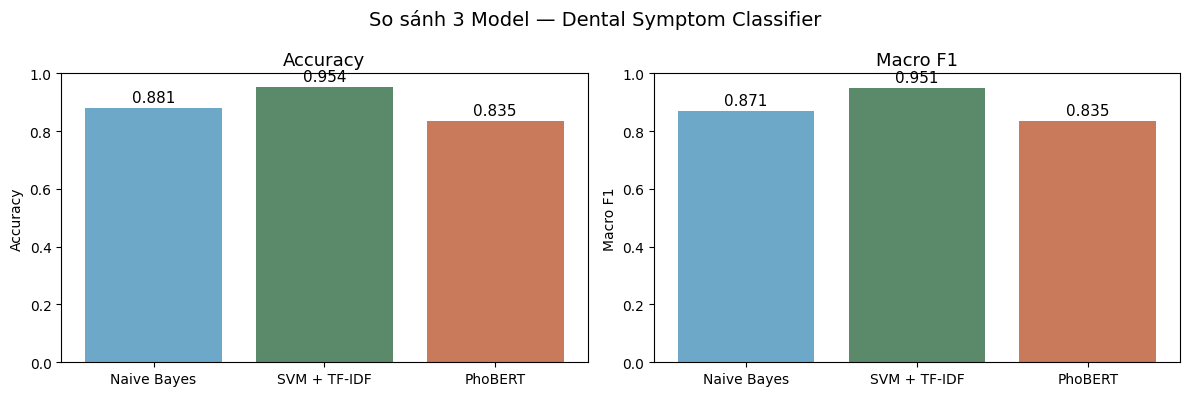

In [15]:
results = pd.DataFrame([
    {'Model': 'Naive Bayes',   'Accuracy': acc_nb,      'Macro F1': f1_nb},
    {'Model': 'SVM + TF-IDF', 'Accuracy': acc_svm,     'Macro F1': f1_svm},
    {'Model': 'PhoBERT',      'Accuracy': acc_phobert, 'Macro F1': f1_phobert},
])
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['Accuracy', 'Macro F1']):
    bars = ax.bar(results['Model'], results[col], color=['#6EA8C8','#5B8A6B','#C87A5B'])
    ax.set_ylim(0, 1)
    ax.set_title(col, fontsize=13)
    ax.set_ylabel(col)
    for bar, val in zip(bars, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11)
plt.suptitle('So sánh 3 Model — Dental Symptom Classifier', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 9. Confusion matrix — model tốt nhất

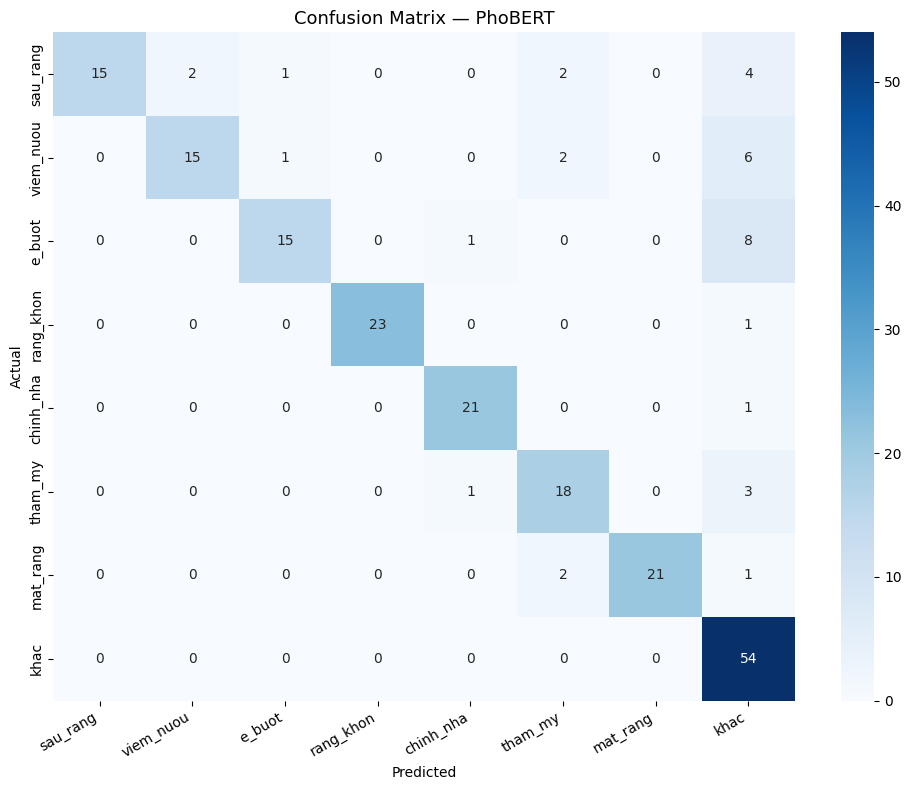

In [16]:
best_preds = y_pred_phobert_labels  # đổi thành y_pred_svm nếu bỏ qua PhoBERT
title      = 'PhoBERT'              # đổi thành 'SVM' nếu bỏ qua PhoBERT

cm = confusion_matrix(y_test, best_preds, labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {title}', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 10. Xuất model để dùng trong FastAPI

In [17]:
import joblib

# SVM pipeline — dùng chính thức trong FastAPI (không cần GPU)
joblib.dump(svm_pipeline, '/kaggle/working/svm_pipeline.joblib')
print('✅ SVM pipeline saved')

# Label map cho FastAPI decode
label_map = {str(i): label for i, label in enumerate(le.classes_)}
with open('/kaggle/working/label_map.json', 'w', encoding='utf-8') as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)
print('✅ label_map.json saved')
print(label_map)

print('\n📁 /kaggle/working/')
for name in sorted(os.listdir('/kaggle/working/')):
    print(' ', name)

✅ SVM pipeline saved
✅ label_map.json saved
{'0': np.str_('chinh_nha'), '1': np.str_('e_buot'), '2': np.str_('khac'), '3': np.str_('mat_rang'), '4': np.str_('rang_khon'), '5': np.str_('sau_rang'), '6': np.str_('tham_my'), '7': np.str_('viem_nuou')}

📁 /kaggle/working/
  __notebook__.ipynb
  confusion_matrix.png
  label_distribution.png
  label_map.json
  model_comparison.png
  phobert_best
  svm_pipeline.joblib


## 11. Test nhanh inference

In [18]:
TEST_SENTENCES = [
    ('Răng tôi bị đau nhức dữ dội, có lỗ đen ở răng hàm',  'sau_rang'),
    ('Răng bị ê buốt khi uống nước lạnh',                   'e_buot'),
    ('Tôi muốn niềng răng cho đều hơn',                     'chinh_nha'),
    ('Răng khôn mọc lệch đau quá phải làm sao',             'rang_khon'),
    ('Nướu bị sưng đỏ và chảy máu khi đánh răng',           'viem_nuou'),
    ('Muốn tẩy trắng răng trước khi đi đám cưới',           'tham_my'),
    ('Răng bị gãy cần trồng lại',                            'mat_rang'),
    ('Phòng khám có mở cửa thứ 7 không?',                   'khac'),
]

print('=== SVM Inference ===')
correct = 0
for sent, expected in TEST_SENTENCES:
    processed = preprocess(sent)
    pred      = svm_pipeline.predict([processed])[0]
    scores    = svm_pipeline.decision_function([processed])[0]
    scores_exp = np.exp(scores - np.max(scores))
    conf      = float(scores_exp.max() / scores_exp.sum())
    ok        = '✅' if pred == expected else '❌'
    if pred == expected:
        correct += 1
    print(f'  {ok} [{pred}] ({conf:.2f}) — {sent[:50]}')
print(f'\nAccuracy trên test sentences: {correct}/{len(TEST_SENTENCES)}')

=== SVM Inference ===
  ❌ [e_buot] (0.26) — Răng tôi bị đau nhức dữ dội, có lỗ đen ở răng hàm
  ✅ [e_buot] (0.47) — Răng bị ê buốt khi uống nước lạnh
  ❌ [e_buot] (0.25) — Tôi muốn niềng răng cho đều hơn
  ✅ [rang_khon] (0.56) — Răng khôn mọc lệch đau quá phải làm sao
  ✅ [viem_nuou] (0.26) — Nướu bị sưng đỏ và chảy máu khi đánh răng
  ✅ [tham_my] (0.46) — Muốn tẩy trắng răng trước khi đi đám cưới
  ❌ [khac] (0.21) — Răng bị gãy cần trồng lại
  ❌ [viem_nuou] (0.16) — Phòng khám có mở cửa thứ 7 không?

Accuracy trên test sentences: 4/8


In [19]:
print('=== PhoBERT Inference ===')
model.eval()
correct = 0
for sent, expected in TEST_SENTENCES:
    processed = preprocess(sent)
    enc = tokenizer(
        processed, max_length=MAX_LEN, padding='max_length',
        truncation=True, return_tensors='pt',
        return_token_type_ids=False
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**enc).logits
    probs   = torch.softmax(logits, dim=1).cpu().numpy()[0]
    top_idx = int(np.argmax(probs))
    pred    = le.inverse_transform([top_idx])[0]
    conf    = float(probs[top_idx])
    ok      = '✅' if pred == expected else '❌'
    if pred == expected:
        correct += 1
    top3 = sorted(enumerate(probs), key=lambda x: -x[1])[:3]
    top3_str = ', '.join(f"{le.inverse_transform([i])[0]}:{p:.2f}" for i,p in top3)
    print(f'  {ok} [{pred}] ({conf:.2f}) — {sent[:45]}')
    print(f'       top3: {top3_str}')
print(f'\nAccuracy trên test sentences: {correct}/{len(TEST_SENTENCES)}')

=== PhoBERT Inference ===
  ❌ [e_buot] (0.23) — Răng tôi bị đau nhức dữ dội, có lỗ đen ở răng
       top3: e_buot:0.23, khac:0.19, viem_nuou:0.18
  ✅ [e_buot] (0.49) — Răng bị ê buốt khi uống nước lạnh
       top3: e_buot:0.49, viem_nuou:0.11, sau_rang:0.09
  ✅ [chinh_nha] (0.18) — Tôi muốn niềng răng cho đều hơn
       top3: chinh_nha:0.18, khac:0.15, rang_khon:0.14
  ✅ [rang_khon] (0.48) — Răng khôn mọc lệch đau quá phải làm sao
       top3: rang_khon:0.48, khac:0.13, mat_rang:0.09
  ❌ [khac] (0.23) — Nướu bị sưng đỏ và chảy máu khi đánh răng
       top3: khac:0.23, viem_nuou:0.23, e_buot:0.20
  ✅ [tham_my] (0.35) — Muốn tẩy trắng răng trước khi đi đám cưới
       top3: tham_my:0.35, sau_rang:0.12, viem_nuou:0.12
  ❌ [khac] (0.42) — Răng bị gãy cần trồng lại
       top3: khac:0.42, mat_rang:0.16, rang_khon:0.12
  ✅ [khac] (0.29) — Phòng khám có mở cửa thứ 7 không?
       top3: khac:0.29, sau_rang:0.15, viem_nuou:0.14

Accuracy trên test sentences: 5/8


## ✅ Tổng kết

| Model | Accuracy | Macro F1 | Ghi chú |
|---|---|---|---|
| Naive Bayes | — | — | Baseline |
| SVM + TF-IDF | — | — | Dùng chính thức trong FastAPI |
| PhoBERT | — | — | Tốt nhất, cho báo cáo |

**Download từ `/kaggle/working/`:**
- `svm_pipeline.joblib` → `ml-service/models/`
- `phobert_best/` (folder) → `ml-service/models/`
- `label_map.json` → `ml-service/models/`

**Chạy FastAPI:**
```bash
MODEL_BACKEND=svm uvicorn main:app --reload --port 8000
```